In [1]:
import mne

# Example file: 'A01T.gdf' = Subject A01, Training session
raw = mne.io.read_raw_gdf('data/raw/A01T.gdf', preload=True)
# print('------------')
# print('raw description:', set(raw.annotations.description))

# print('------------')
# print('raw: ', raw)
# print('------------')
# for i, desc in enumerate(raw.annotations.description):
#     print(f"{i:3}: {desc}")
# print('------------')

raw.filter(7., 30., fir_design='firwin')  # Optional: band-pass filter for motor imagery

# Event IDs for motor imagery (typically: 769 = left, 770 = right, 771 = feet, 772 = tongue)



# raw.plot_psd()	

events, event_id_map = mne.events_from_annotations(raw)
event_id = {
    'left_hand': event_id_map['769'],
    'right_hand': event_id_map['770'],
    'feet': event_id_map['771'],
    'tongue': event_id_map['772']
}
print('Extracted event_id_map', event_id_map)

# Crop data from 0.5s to 4.5s after cue (motor imagery window)
epochs = mne.Epochs(raw, events, event_id, tmin=2.0, tmax=5.0, baseline=None, preload=True)
X = epochs.get_data()  # shape: (n_trials, n_channels, n_times)
y = epochs.events[:, -1]  # labels\
    
print("EEG shape:", X.shape)
print("Labels shape:", y.shape)
    

# Plot raw EEG



Extracting EDF parameters from /Users/temp/Documents/Bath University/Msc/Disseration /EEG_Project/data/raw/A01T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...


/Users/temp/anaconda3/envs/robust_eeg/lib/python3.10/contextlib.py:142: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Reading 0 ... 672527  =      0.000 ...  2690.108 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done  25 out of  25 | elapsed:    0.4s finished


Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Extracted event_id_map {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10}
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 751 original time points ...
0 bad epochs dropped
EEG shape: (288, 25, 751)
Labels shape: (288,)


In [27]:
raw.plot(n_channels=2, scalings='auto')


Using pyopengl with version 3.1.9


In [ ]:
epochs[0].plot()

Using pyopengl with version 3.1.9


: 

In [8]:
epochs.info['ch_names']

['EEG-Fz',
 'EEG-0',
 'EEG-1',
 'EEG-2',
 'EEG-3',
 'EEG-4',
 'EEG-5',
 'EEG-C3',
 'EEG-6',
 'EEG-Cz',
 'EEG-7',
 'EEG-C4',
 'EEG-8',
 'EEG-9',
 'EEG-10',
 'EEG-11',
 'EEG-12',
 'EEG-13',
 'EEG-14',
 'EEG-Pz',
 'EEG-15',
 'EEG-16',
 'EOG-left',
 'EOG-central',
 'EOG-right']

In [ ]:
# import matplotlib.pyplot as plt

# plt.plot(X[0][0])  # Trial 0, Channel 0
# plt.title("EEG signal from Channel 0 of Trial 0")
# plt.xlabel("Time (samples)")


In [10]:
ch_index = epochs.info['ch_names'].index('EEG-14')
print()

18


In [20]:
data = epochs[10:50].get_data()[0, ch_index,:]


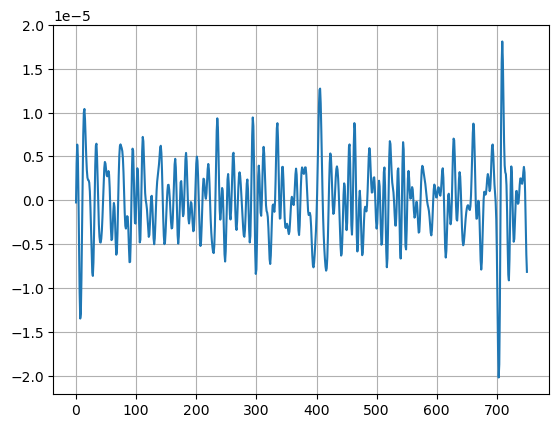

In [21]:
from matplotlib import pyplot as plt
plt.plot(data)
plt.grid(True)
plt.show()

In [ ]:

left_epochs = epochs['left_hand']
left_epochs.plot(n_epochs=10, title="Left-hand Motor Imagery Trials")


Using pyopengl with version 3.1.9


Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


Not setting metadata
72 matching events found
No baseline correction applied
0 projection items activated


/var/folders/lh/djcqdsjd0fdbmg090v1g_mwh0000gn/T/ipykernel_10358/1353517103.py:1: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  left_epochs.plot_image(picks='EEG-14', title='Left-hand Trials – Channel EEG-14')


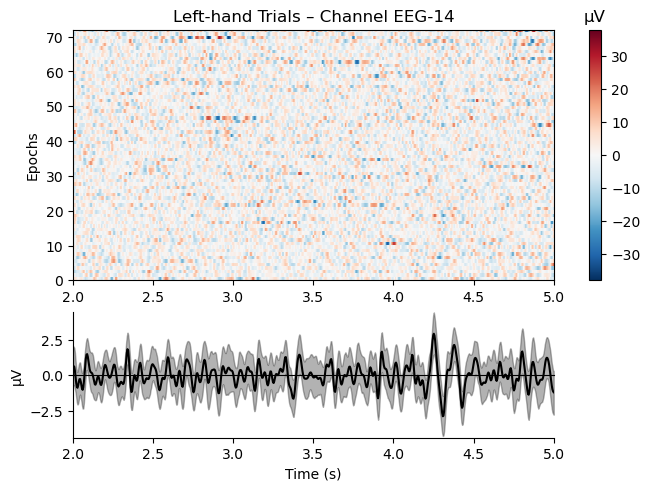

[<Figure size 640x480 with 3 Axes>]

In [14]:
left_epochs.plot_image(picks='EEG-14', title='Left-hand Trials – Channel EEG-14')



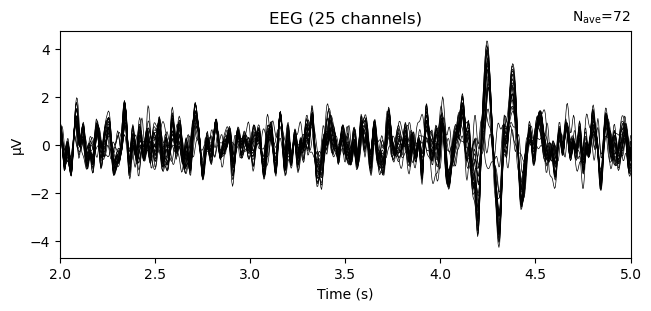

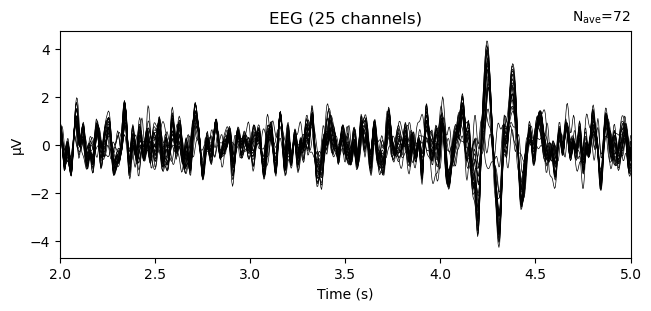

In [ ]:
left_avg = left_epochs.average()

left_avg.plot()

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).


/var/folders/lh/djcqdsjd0fdbmg090v1g_mwh0000gn/T/ipykernel_10358/3380781713.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  epochs['tongue'].average().plot_psd()
/Users/temp/anaconda3/envs/robust_eeg/lib/python3.10/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


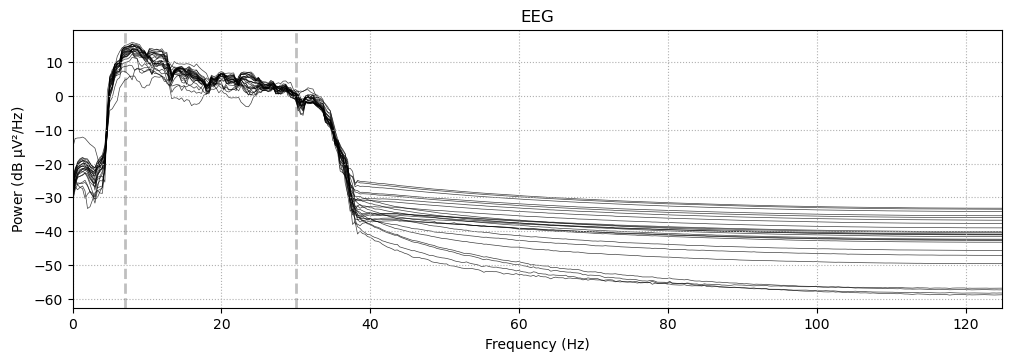

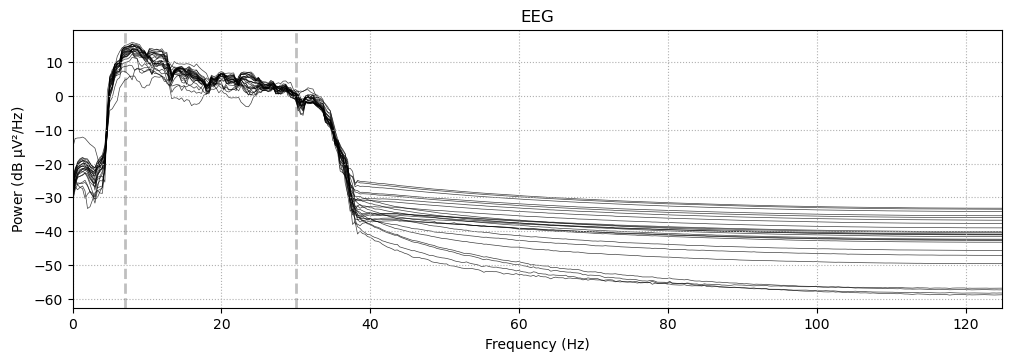

In [ ]:
epochs['tongue'].average().plot_psd()

/var/folders/lh/djcqdsjd0fdbmg090v1g_mwh0000gn/T/ipykernel_10358/3061972418.py:5: RuntimeWarning: Cannot find channel coordinates in the supplied Evokeds. Not showing channel locations.
  mne.viz.plot_compare_evokeds(


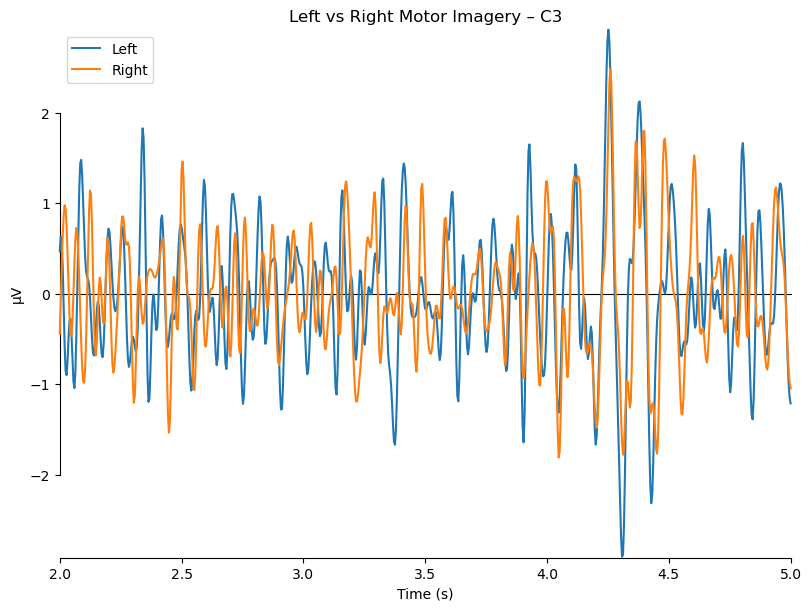

[<Figure size 800x600 with 1 Axes>]

In [32]:
left_avg = epochs['left_hand'].average()
right_avg = epochs['right_hand'].average()

# Overlay them
mne.viz.plot_compare_evokeds(
    {'Left': left_avg, 'Right': right_avg},
    picks='EEG-14',  # or 'C4' or 'Cz'
    title='Left vs Right Motor Imagery – C3'
)


Before rename: ['Fz', 'C3', 'Cz', 'C4', 'Pz', 'EOG1', 'EOG2', 'EOG3']


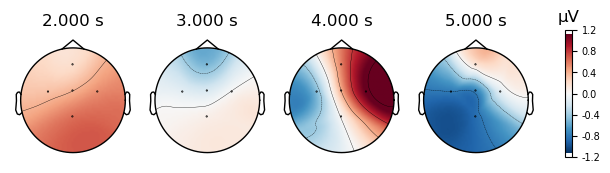

Text(0.5, 0.98, 'Left-hand Motor Imagery')

In [24]:
# Check original channels
print("Before rename:", epochs.ch_names)

# Only rename channels that are actually in the current object
available = set(epochs.ch_names)

rename_dict = {
    old: new for old, new in {
        'EEG-Fz': 'Fz',
        'EEG-C3': 'C3',
        'EEG-Cz': 'Cz',
        'EEG-C4': 'C4',
        'EEG-Pz': 'Pz',
        'EOG-left': 'EOG1',
        'EOG-central': 'EOG2',
        'EOG-right': 'EOG3'
    }.items() if old in available
}

# Rename only if needed
if rename_dict:
    epochs.rename_channels(rename_dict)

# Set EOG channel types
epochs.set_channel_types({'EOG1': 'eog', 'EOG2': 'eog', 'EOG3': 'eog'})
# Now set montage - it will only apply to EEG channels
epochs.set_montage('standard_1020')

# Now create evoked and plot
left_evoked = epochs['left_hand'].average()

# Use automatic time selection
fig = left_evoked.plot_topomap(ch_type='eeg', time_unit='s')

fig.suptitle("Left-hand Motor Imagery", fontsize=14)


hell
None
['Fz', 'EEG0', 'EEG1', 'EEG2', 'EEG3', 'EEG4', 'EEG5', 'C3', 'EEG6', 'Cz', 'EEG7', 'C4', 'EEG8', 'EEG9', 'EEG10', 'EEG11', 'EEG12', 'EEG13', 'EEG14', 'Pz', 'EEG15', 'EEG16', 'EOG1', 'EOG2', 'EOG3']


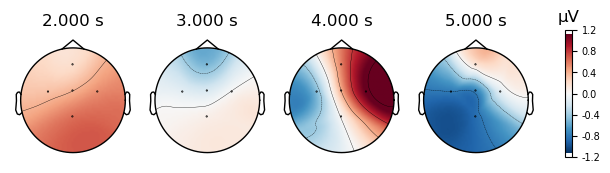

Text(0.5, 0.98, 'Left-hand Motor Imagery')